In [108]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F

CLEANED_DATA_DIR = Path("../data/cleaned")

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
co2_df = spark.read.parquet(f"{CLEANED_DATA_DIR}/4c_eea_co2_emissions_from_passenger_cars-001.parquet")
eurostat_df = spark.read.csv('../data/cleaned/2c_eurostat_new_passenger_cars_by_type_of_motor_energy.csv', header=True)

Rename "Petrol plug-in Hybrid" to "Petrol plug-in hybrid" in the EEA co2 dataset to ensure consistency with the Eurostat dataset. 

In [109]:
co2_df = co2_df.withColumn(
    "Motor energy",
    F.when(
        F.col("Motor energy") == "Petrol plug-in Hybrid",
        "Petrol plug-in hybrid"
    )
    .otherwise(F.col("Motor energy"))
)

Add in the EEA dataset for the 'Motor energy' column the values:
- 'Petrol' as the sum of the values 'Petrol (excluding hybrids)', Petrol plug-in Hybrid, Petrol hybrid;
- 'Diesel' as the sum of the values 'Diesel (excluding hybrids)', Diesel hybrid;

In [110]:
eea_detailed = (
    co2_df
    .groupBy(
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD",
        "Motor energy"
    )
    .agg(
        F.sum("registrations").alias("registrations")
    )
)

eea_detailed.show(20, truncate=False)

+---+-------------------------------+-----------+--------------------------+-------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|Motor energy              |registrations|
+---+-------------------------------+-----------+--------------------------+-------------+
|FI |Finland                        |2015       |Diesel (excluding hybrids)|36603        |
|IT |Italy                          |2017       |Diesel (excluding hybrids)|1112208      |
|IT |Italy                          |2017       |Petrol hybrid             |3742         |
|IT |Italy                          |2020       |Petrol hybrid             |28388        |
|LT |Lithuania                      |2019       |Petrol hybrid             |59           |
|HU |Hungary                        |2021       |Diesel (excluding hybrids)|25289        |
|ES |Spain                          |2019       |Petrol hybrid             |7308         |
|RO |Romania                        |2022       |Petrol hybrid             |3688         |

- 'Petrol' = 'Petrol (excluding hybrids)' + 'Petrol plug-in Hybrid' + 'Petrol hybrid'
- 'Diesel' = 'Diesel (excluding hybrids)' + 'Diesel hybrid'

In [111]:
eea_petrol = (
    eea_detailed
    .filter(
        F.col("Motor energy").isin(
            "Petrol (excluding hybrids)",
            "Petrol hybrid",
            "Petrol plug-in hybrid"
        )
    )
    .groupBy(
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD"
    )
    .agg(
        F.sum("registrations").alias("registrations")
    )
    .withColumn(
        "Motor energy",
        F.lit("Petrol")
    )
)

eea_diesel = (
    eea_detailed
    .filter(
        F.col("Motor energy").isin(
            "Diesel (excluding hybrids)",
            "Diesel hybrid"
        )
    )
    .groupBy(
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD"
    )
    .agg(
        F.sum("registrations").alias("registrations")
    )
    .withColumn(
        "Motor energy",
        F.lit("Diesel")
    )
)

eea_complete = (
    eea_detailed
    .unionByName(eea_petrol)
    .unionByName(eea_diesel)
    .orderBy("geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy")
)

eea_complete.show(20, truncate=False)

+---+-------------------------------+-----------+--------------------------+-------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|Motor energy              |registrations|
+---+-------------------------------+-----------+--------------------------+-------------+
|AT |Austria                        |2013       |Alternative/Other         |691          |
|AT |Austria                        |2013       |Diesel                    |180688       |
|AT |Austria                        |2013       |Diesel (excluding hybrids)|180688       |
|AT |Austria                        |2013       |Electricity               |653          |
|AT |Austria                        |2013       |Petrol                    |136614       |
|AT |Austria                        |2013       |Petrol (excluding hybrids)|136608       |
|AT |Austria                        |2013       |Petrol hybrid             |6            |
|AT |Austria                        |2014       |Alternative/Other         |795          |

Check the distinct values of the 'Motor energy' column in both datasets to ensure consistency.

In [112]:
eea_complete.select("Motor energy").distinct().orderBy("Motor energy").show(20, truncate=False)

+--------------------------+
|Motor energy              |
+--------------------------+
|Alternative/Other         |
|Diesel                    |
|Diesel (excluding hybrids)|
|Diesel hybrid             |
|Electricity               |
|Petrol                    |
|Petrol (excluding hybrids)|
|Petrol hybrid             |
|Petrol plug-in hybrid     |
+--------------------------+



In [113]:
eurostat_df.select("Motor energy").distinct().orderBy("Motor energy").show(20, truncate=False)

+--------------------------+
|Motor energy              |
+--------------------------+
|Diesel                    |
|Diesel (excluding hybrids)|
|Diesel hybrid             |
|Diesel plug-in hybrid     |
|Electricity               |
|Other                     |
|Petrol                    |
|Petrol (excluding hybrids)|
|Petrol hybrid             |
|Petrol plug-in hybrid     |
|Total                     |
+--------------------------+



### Heatmap years vs. motor energy with values as percentage_difference between the EEA and the Eurostat dataset.

Prepare the data for the heatmap by creating the 'eea_registrations' and 'eurostat_registrations' columns, which represent the number of registrations for each 'geo', 'TIME_PERIOD', and 'Motor energy' combination. Then calculate the percentage difference between the two datasets using the formula:

$percentage\_difference = ((eea_{registrations} - eurostat_{registrations}) / eurostat_{registrations}) * 100$

In [114]:
eea = eea_complete.groupBy("geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy").agg(
    F.sum("registrations").alias("eea_registrations")
)

eurostat = eurostat_df.groupBy("geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy").agg(
    F.sum(F.col("OBS_VALUE").cast("double")).alias("eurostat_registrations")
)

comparison = (
    eea.join(eurostat, ["geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "Motor energy"], "inner")
    .fillna(0, subset=["eea_registrations", "eurostat_registrations"])
)

comparison.show(20, truncate=False)

+---+-------------------------------+-----------+--------------------------+-----------------+----------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|Motor energy              |eea_registrations|eurostat_registrations|
+---+-------------------------------+-----------+--------------------------+-----------------+----------------------+
|FI |Finland                        |2015       |Diesel (excluding hybrids)|36603            |38800.0               |
|IT |Italy                          |2017       |Diesel (excluding hybrids)|1112208          |1130434.0             |
|LT |Lithuania                      |2019       |Petrol hybrid             |59               |3200.0                |
|HU |Hungary                        |2021       |Diesel (excluding hybrids)|25289            |19092.0               |
|ES |Spain                          |2019       |Petrol hybrid             |7308             |92605.0               |
|RO |Romania                        |2016       |Petrol 

In [115]:
heatmap_df = (
    comparison.groupBy("Motor energy", "TIME_PERIOD")
    .agg(
        F.sum("eea_registrations").alias("eea_total"),
        F.sum("eurostat_registrations").alias("eurostat_total"),
    )
    .withColumn(
        "percentage_difference",
        F.when(F.col("eurostat_total") == 0, F.when(F.col("eea_total") == 0, 0).otherwise(100))
        .otherwise(((F.col("eea_total") - F.col("eurostat_total")) / F.col("eurostat_total")) * 100)
    )
    .toPandas()
    .pivot(
        index="Motor energy", columns="TIME_PERIOD", values="percentage_difference"
    )
)

heatmap_df.rename(index={"Petrol": "Petrol (all)", "Diesel": "Diesel (all)"}, inplace=True)

display(heatmap_df)

TIME_PERIOD,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Motor energy,,,,,,,,,,
Diesel (all),-0.416674,0.893016,-0.002853,-1.005401,-2.048812,-2.064427,-3.470189,-4.705100,-4.515407,-5.821539
Diesel (excluding hybrids),0.002077,2.402502,1.144888,-0.943781,-1.289810,1.161422,4.093259,13.035117,17.428776,21.268036
Diesel hybrid,-89.105661,-94.591985,-70.217656,-28.780083,-88.060240,-90.261921,-82.395028,-85.379060,-88.109881,-92.849412
Electricity,0.328164,0.422538,0.878505,0.106284,-0.302902,-2.949250,-0.074501,-0.328363,-1.557109,0.342503
Petrol (all),0.773216,0.527947,-1.872472,-1.307815,-0.971703,-1.336465,-1.224076,-0.582265,-1.530177,0.035200
Petrol (excluding hybrids),2.158131,3.941783,-1.000098,2.740518,4.262930,6.082495,17.475511,37.463535,48.412337,59.069061
Petrol hybrid,-68.057115,-58.935349,-72.060462,-71.995130,-74.112342,-76.317288,-43.554892,-49.410883,-53.393761,-65.244312
Petrol plug-in hybrid,NaN,-88.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


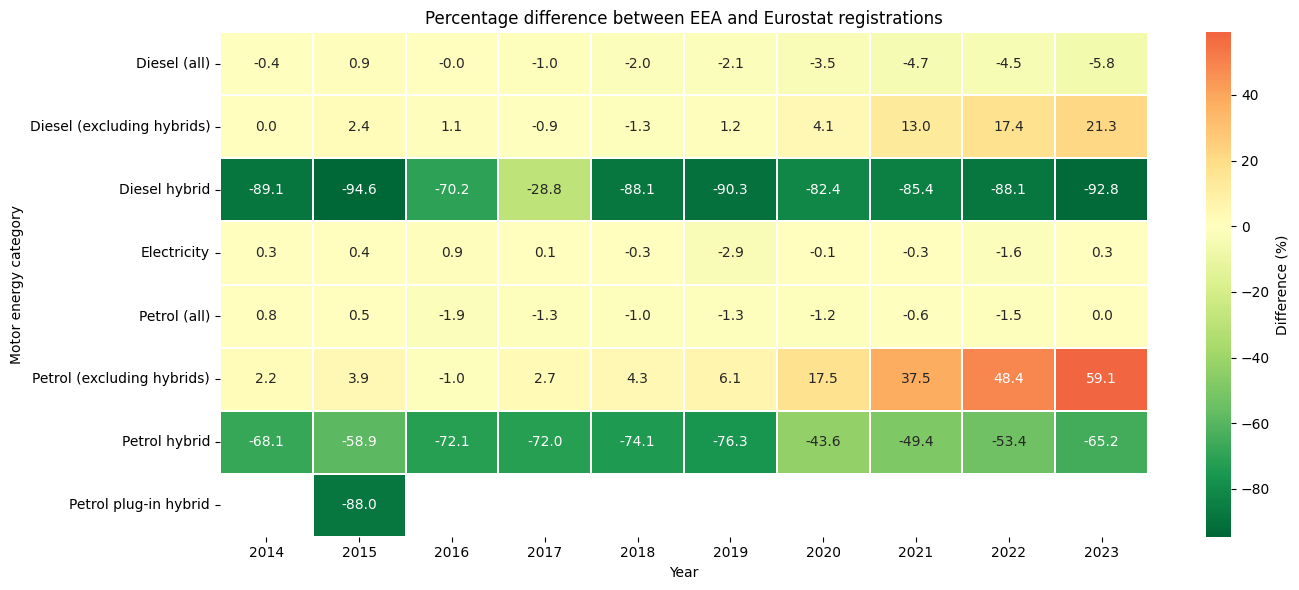

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.3,
    cbar_kws={
        "label": "Difference (%)"
    }
)

plt.xlabel("Year")
plt.ylabel("Motor energy category")

plt.title("Percentage difference between EEA and Eurostat registrations")

plt.tight_layout()
plt.show()

> Both datasets agree on the overall fuel family, but not necessarily on the hybrid classification!

NOTE: The calculation yields extreme values for specific hybrid/non-hybrid categories, while standard categories (Petrol, Diesel, Electricity) remain stable near 0%. This confirms that both datasets agree on the overall fuel family volume, but differ heavily on how hybrids are classified. The massive positive gap in "excluding hybrids" perfectly mirrors the negative gap in "hybrids", indicating a pure taxonomy misalignment rather than a data collection error.

### Heatmap geo vs. motor energy with values as percentage_difference between the EEA and the Eurostat dataset.

In [117]:
heatmap_df = (
    comparison.groupBy("Geopolitical entity (reporting)", "TIME_PERIOD")
    .agg(
        F.sum("eea_registrations").alias("eea_total"),
        F.sum("eurostat_registrations").alias("eurostat_total"),
    )
    .withColumn(
        "percentage_difference",
        F.when(F.col("eurostat_total") == 0, F.when(F.col("eea_total") == 0, 0).otherwise(100))
        .otherwise(((F.col("eea_total") - F.col("eurostat_total")) / F.col("eurostat_total")) * 100)
    )
    .toPandas()
    .pivot(
        index="Geopolitical entity (reporting)", columns="TIME_PERIOD", values="percentage_difference"
    )
)

display(heatmap_df)

TIME_PERIOD,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Geopolitical entity (reporting),,,,,,,,,,
Austria,-0.079226,0.076031,0.083134,0.131260,0.154207,-0.008048,0.520268,2.979968,3.125123,3.789393
Belgium,-0.483067,-0.618145,-0.927943,-0.945541,-1.745347,-2.017491,-1.974792,-2.386271,6.702786,11.119571
Bulgaria,NaN,NaN,227.272727,661.538462,34.482759,55.851064,1.610905,-8.316101,-7.650361,-9.441506
Croatia,-72.340426,2.500000,-16.666667,-80.000000,-43.406593,-44.444444,-2.816302,29.940256,16.507914,30.102825
Cyprus,-3.264813,-8.964203,-6.845358,-2.740458,-2.865089,-4.748648,-4.390172,-1.111322,-0.119904,-0.722047
Czechia,NaN,-28.846154,-65.714286,-46.010638,-24.623803,-15.167095,-2.612609,-1.888324,5.850716,3.554734
Denmark,-0.263678,-3.517620,-0.597516,-0.853208,-1.870428,-1.292576,3.108247,9.248878,-53.292364,5.677008
Estonia,-0.854599,-0.304284,-0.649972,0.335951,-0.072469,-0.938705,-4.176442,-1.864053,-1.837210,-0.880575
Finland,-2.991141,-2.729448,-2.646374,-2.420997,-1.773543,-2.101676,4.335442,8.105976,8.787238,10.717731


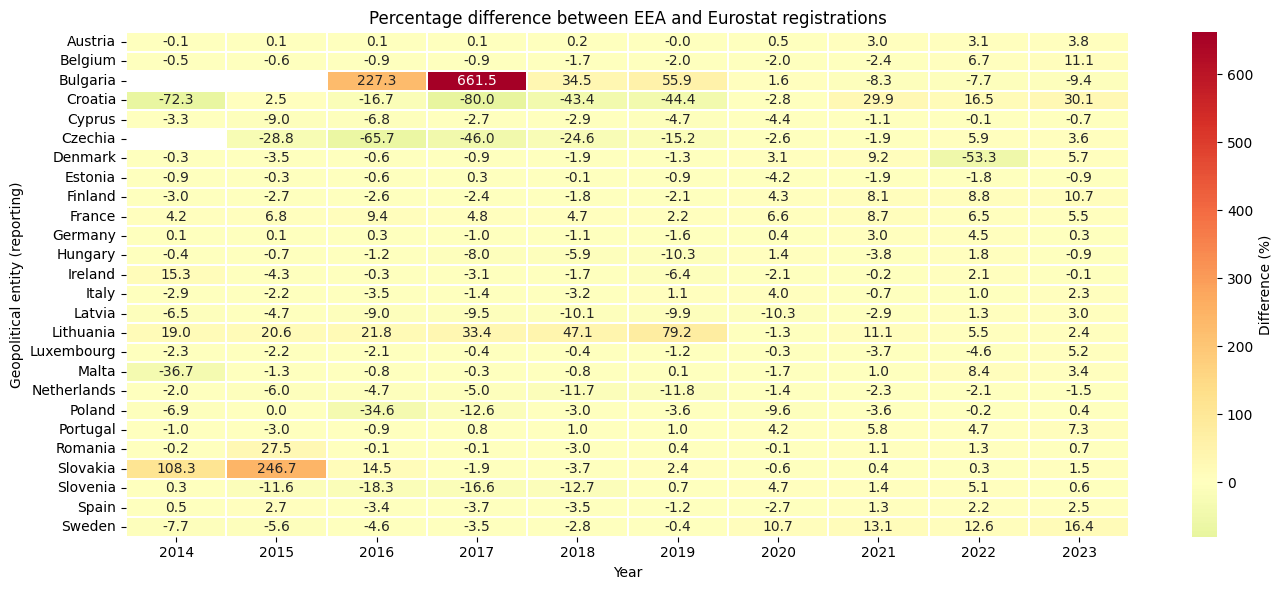

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.3,
    cbar_kws={
        "label": "Difference (%)"
    }
)

plt.xlabel("Year")
plt.ylabel("Geopolitical entity (reporting)")

plt.title("Percentage difference between EEA and Eurostat registrations")

plt.tight_layout()
plt.show()